In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../")

In [3]:
from mbt_gym.agents.BaselineAgents import CarteaJaimungalMmAgent
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.wrappers import *
from mbt_gym.rewards.RewardFunctions import PnL, CjMmCriterion
from mbt_gym.stochastic_processes.midprice_models import BrownianMotionMidpriceModel
from mbt_gym.stochastic_processes.arrival_models import PoissonArrivalModel
from mbt_gym.stochastic_processes.fill_probability_models import ExponentialFillFunction
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics

### Create market making environment

Parameters
(avalledana paper found if q=0 and psi =0 no fad no informed)

## AvellanedaStoikov

In [4]:
import sys
sys.path.append("../") # This version of the notebook is in the subfolder "notebooks" of the repo

import gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from copy import deepcopy


from mbt_gym.agents.BaselineAgents import *
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *
import torch
#print(torch.cuda.is_available())
#print(torch.cuda.get_device_name())
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
seed = 50


## Replication of Avellaneda Stoikov result with ArithmeticBrownianMotionWithFadsMidpriceModel (fads_propportion=0)

In [5]:
from mbt_gym.stochastic_processes.midprice_models import ArithmeticBrownianMotionWithFadsMidpriceModel

In [6]:
# lambda_a = (phi + psi * exp(-gamma * (sigma * q * Ut))) * exp(-k * delta_a)
# lambda_b = (phi + psi * exp(-gamma * (sigma * q * Ut))) * exp(-k * delta_b)


In [7]:
def get_as_env(num_trajectories:int = 1):
    initial_price = 100
    terminal_time = 1.0
    sigma = 2.0
    n_steps = 200
    initial_inventory = 0
    arrival_rate = 140
    fill_exponent = 1.5
    fads_proportion = 0
    # gamma = 1
    eta = 2
    # k = gamma
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=1/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories)
    arrival_model = FadsInformedUniformedTradersArrivalModel(
    num_trajectories=1,
    seed=42
)
    fill_probability_model = ExponentialFillFunction(fill_exponent=fill_exponent, 
                                                     step_size=1/n_steps,
                                                     num_trajectories=num_trajectories)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [8]:
as_env = get_as_env()

In [9]:
as_agent = MMwithFadsInformedUniformedTradersAgent(env=as_env)
print(as_env.model_dynamics
      .midprice_model)


Step [[ 0.00000000e+00  0.00000000e+00  5.00000000e-03  9.99120219e+01
  -4.06664768e-02 -1.20596126e+01  4.24306804e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  1.00000000e-02  1.00089148e+02
  -3.45849410e-02 -1.20733894e+01  4.17493640e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  1.50000000e-02  9.99333523e+01
  -5.71420414e-02 -1.20547953e+01  4.16163611e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  2.00000000e-02  1.00184722e+02
  -1.13049722e-01 -1.20813586e+01  4.05159793e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  2.50000000e-02  1.00017332e+02
  -1.36696944e-01 -1.20486677e+01  3.91955005e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  3.00000000e-02  1.00059514e+02
  -1.56705055e-01 -1.20486558e+01  3.85372889e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  3.50000000e-02  1.00322986e+02
  -1.34836822e-01 -1.20770078e+01  3.84733594e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  4.00000000e-02  1.00104399e+02
  -1.47022287e-01 -1.20539154e+01  3.87556140e-01]]
Step [[ 0.000000

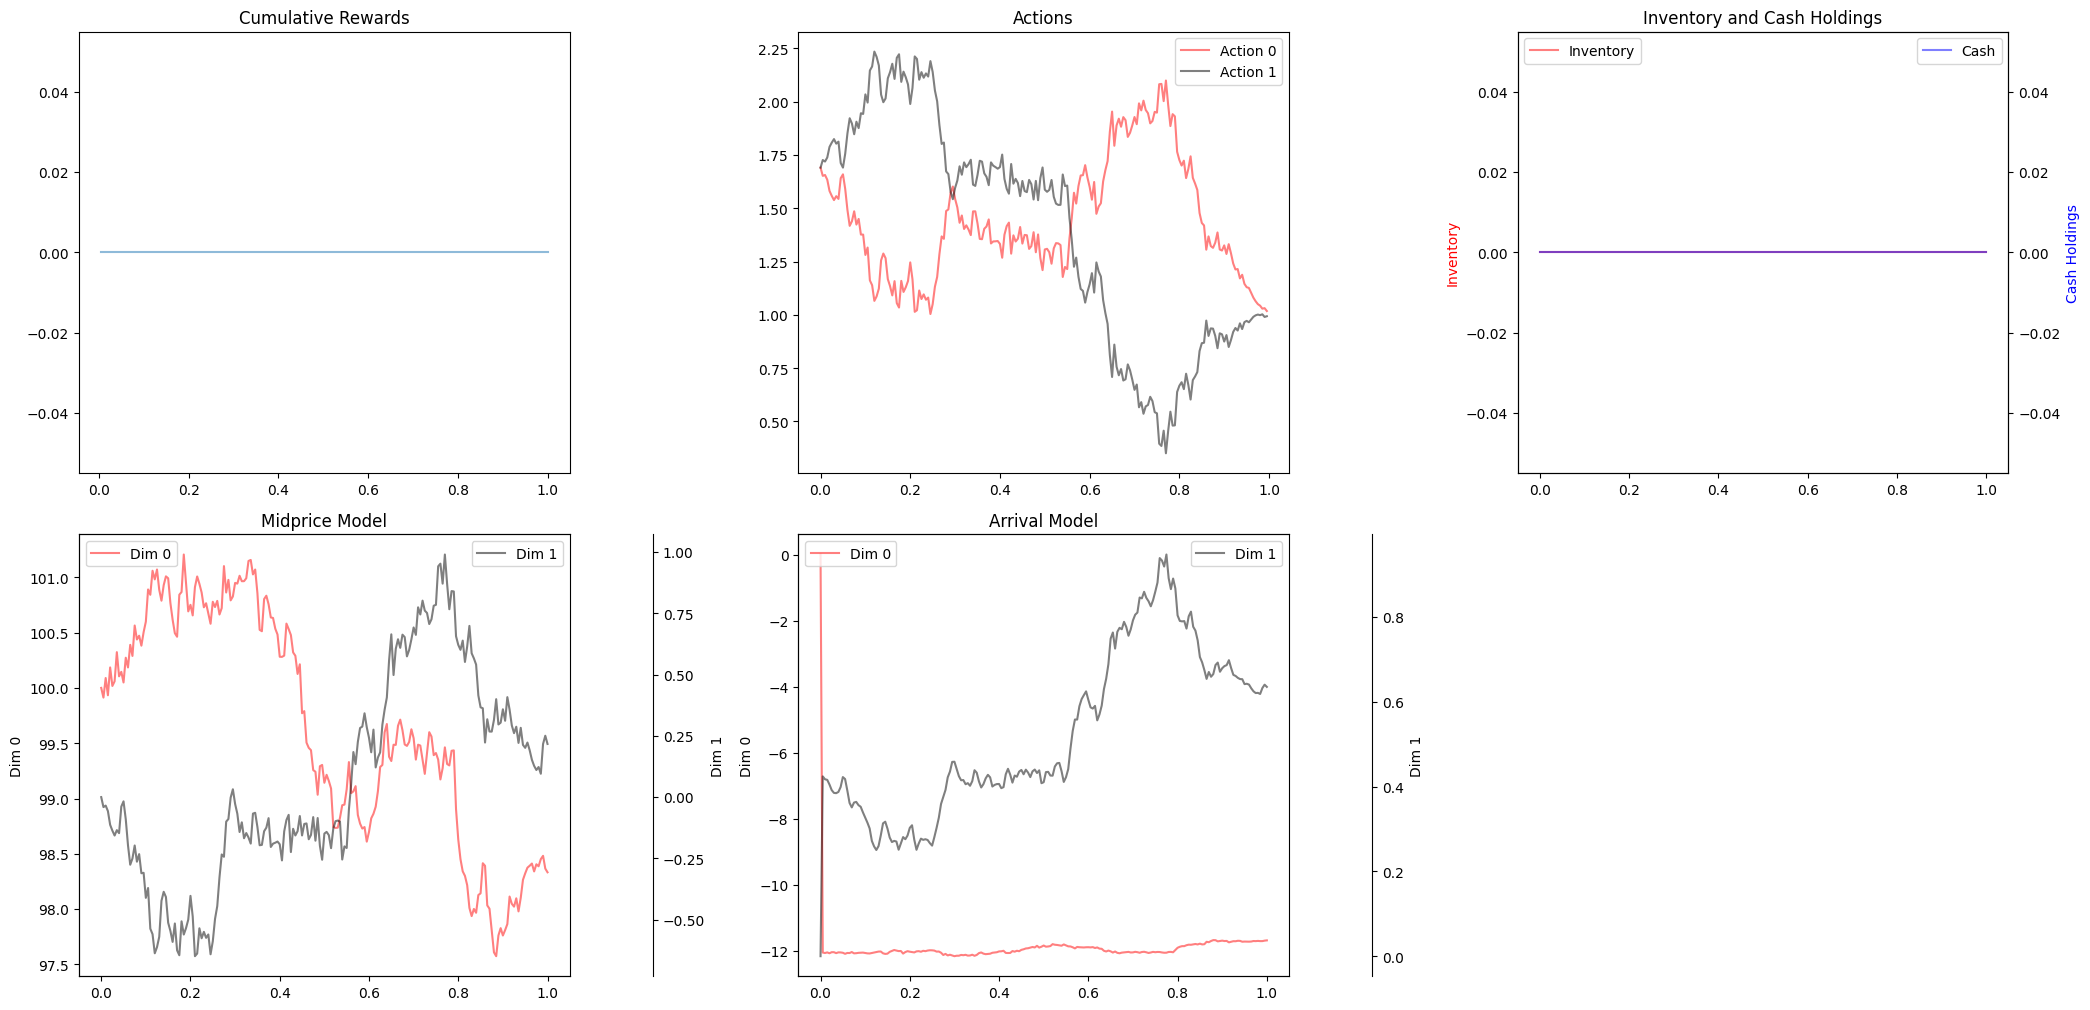

In [10]:
plot_trajectory_extended(as_env, as_agent)

Step [[ 0.00000000e+00  0.00000000e+00  5.00000000e-03  9.99120219e+01
  -4.06664768e-02 -1.20596126e+01  4.24306804e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  1.00000000e-02  1.00089148e+02
  -3.45849410e-02 -1.20733894e+01  4.17493640e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  1.50000000e-02  9.99333523e+01
  -5.71420414e-02 -1.20547953e+01  4.16163611e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  2.00000000e-02  1.00184722e+02
  -1.13049722e-01 -1.20813586e+01  4.05159793e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  2.50000000e-02  1.00017332e+02
  -1.36696944e-01 -1.20486677e+01  3.91955005e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  3.00000000e-02  1.00059514e+02
  -1.56705055e-01 -1.20486558e+01  3.85372889e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  3.50000000e-02  1.00322986e+02
  -1.34836822e-01 -1.20770078e+01  3.84733594e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  4.00000000e-02  1.00104399e+02
  -1.47022287e-01 -1.20539154e+01  3.87556140e-01]]
Step [[ 0.000000

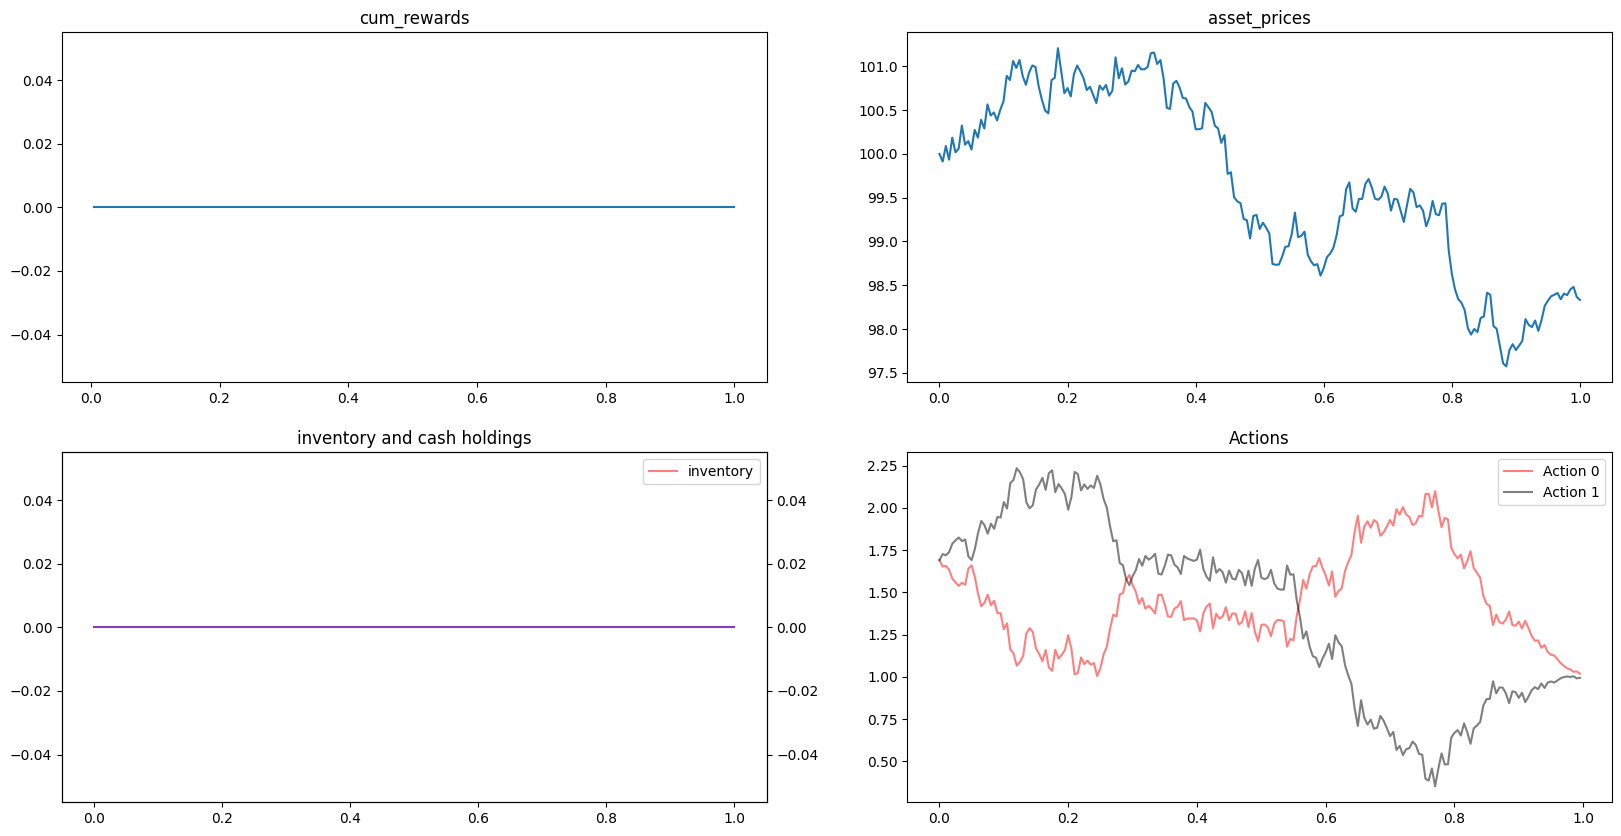

In [11]:
plot_trajectory(as_env, as_agent, seed = 50)

### Comparing the results to the Avellaneda Stoikov paper $\gamma = 0.1$

In [12]:
num_trajectories = 1000
vec_env = get_as_env(num_trajectories)
vec_as = MMwithFadsInformedUniformedTradersAgent(env=vec_env)

In [13]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

Step [[ 0.00000000e+00  0.00000000e+00  5.00000000e-03 ... -4.06664768e-02
  -1.20596126e+01  4.24306804e-01]
 [ 0.00000000e+00  0.00000000e+00  5.00000000e-03 ...  5.67487100e-03
  -1.20927507e+01  4.30099472e-01]
 [ 0.00000000e+00  0.00000000e+00  5.00000000e-03 ... -2.29029497e-02
  -1.20511354e+01  4.26527244e-01]
 ...
 [ 0.00000000e+00  0.00000000e+00  5.00000000e-03 ... -2.27761171e-02
  -1.20633741e+01  4.26543099e-01]
 [ 0.00000000e+00  0.00000000e+00  5.00000000e-03 ... -3.97115666e-02
  -1.20820732e+01  4.24426167e-01]
 [ 0.00000000e+00  0.00000000e+00  5.00000000e-03 ...  1.07278402e-02
  -1.20537863e+01  4.30731093e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  1.00000000e-02 ... -2.93241726e-02
  -1.20516218e+01  4.18151236e-01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e-02 ... -2.74090385e-02
  -1.20944416e+01  4.27398825e-01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e-02 ...  4.04581021e-02
  -1.20654263e+01  4.30304556e-01]
 ...
 [ 0.00000000e+00  0.00000000e+00 

/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/../mbt_gym/agents/BaselineAgents.py:254: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")


Step [[ 0.00000000e+00  0.00000000e+00  2.20000000e-01 ... -5.65799313e-01
  -1.19080519e+01  2.72270533e-01]
 [ 0.00000000e+00  0.00000000e+00  2.20000000e-01 ...  3.38192317e-01
  -1.21548552e+01  5.61056844e-01]
 [ 0.00000000e+00  0.00000000e+00  2.20000000e-01 ... -2.11150033e-03
  -1.20671822e+01  4.22650875e-01]
 ...
 [ 0.00000000e+00  0.00000000e+00  2.20000000e-01 ... -5.11843896e-01
  -1.18039748e+01  2.79560431e-01]
 [ 0.00000000e+00  0.00000000e+00  2.20000000e-01 ...  1.97532074e-01
  -1.21280157e+01  5.20945015e-01]
 [ 0.00000000e+00  0.00000000e+00  2.20000000e-01 ... -1.65085863e-01
  -1.20001330e+01  3.80448762e-01]]
Step [[  0.           0.           0.225      ...  -0.39786834 -11.91658725
    0.29473739]
 [  0.           0.           0.225      ...   0.27576072 -12.19177466
    0.55743124]
 [  0.           0.           0.225      ...   0.06346872 -12.09571079
    0.4548368 ]
 ...
 [  0.           0.           0.225      ...  -0.58935125 -11.83131805
    0.27949362]
 

In [14]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

Step [[ 0.00000000e+00  0.00000000e+00  5.00000000e-03 ...  3.80807163e-02
  -1.20705564e+01  4.34150203e-01]
 [ 0.00000000e+00  0.00000000e+00  5.00000000e-03 ...  3.92225787e-02
  -1.20698095e+01  4.34292936e-01]
 [ 0.00000000e+00  0.00000000e+00  5.00000000e-03 ... -4.26608806e-02
  -1.20686588e+01  4.24057503e-01]
 ...
 [ 0.00000000e+00  0.00000000e+00  5.00000000e-03 ...  5.20404089e-02
  -1.20760422e+01  4.35895164e-01]
 [ 0.00000000e+00  0.00000000e+00  5.00000000e-03 ... -7.75554143e-02
  -1.20612504e+01  4.19695686e-01]
 [ 0.00000000e+00  0.00000000e+00  5.00000000e-03 ... -1.04404083e-01
  -1.20845832e+01  4.16339603e-01]]
Step [[ 0.00000000e+00  0.00000000e+00  1.00000000e-02 ...  2.91170891e-02
  -1.20797933e+01  4.40877951e-01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e-02 ...  9.26212363e-02
  -1.20620961e+01  4.49043685e-01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e-02 ...  3.98262657e-02
  -1.20318118e+01  4.26411609e-01]
 ...
 [ 0.00000000e+00  0.00000000e+00 

In [15]:
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.826567,0.223008,0.759451,-0.186,0.423561


## Replication of Avellaneda Stoikov result with ArithmeticBrownianMotionWithFadsMidpriceModel and MMwithFadsInformedUniformedTradersAgent (fads_proportion=0 and psi=0)

In [16]:
from mbt_gym.stochastic_processes.midprice_models import ArithmeticBrownianMotionWithFadsMidpriceModel

In [17]:
def get_as_env(num_trajectories:int = 1):
    initial_price = 100
    terminal_time = 1.0
    sigma = 2.0
    n_steps = 200
    initial_inventory = 0
    arrival_rate = 140
    fill_exponent = 0
    fads_proportion = 0
    initial_fad=0
    # gamma = 1
    eta = 10
    # k = gamma
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price,
                                                 volatility=sigma, fads_proportion=fads_proportion, initial_fad=initial_fad, eta=eta, step_size=1/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories)
    arrival_model = PoissonArrivalModel(intensity=np.array([arrival_rate, arrival_rate]), 
                                        step_size=1/n_steps, 
                                        num_trajectories=num_trajectories)
    fill_probability_model = ExponentialFillFunction(fill_exponent=fill_exponent, 
                                                     step_size=1/n_steps,
                                                     num_trajectories=num_trajectories)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [18]:
as_env = get_as_env()

/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/../mbt_gym/stochastic_processes/fill_probability_models.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  return -np.log(0.01) / self.fill_exponent


In [19]:
as_agent = MMwithFadsInformedUniformedTradersAgent(risk_aversion=0.1, env=as_env)
print(as_env.model_dynamics
      .midprice_model)

Step [[ 3.38155767e+00  0.00000000e+00  5.00000000e-03  9.99120219e+01
  -4.06664768e-02]]
Step [[ 6.76012189e+00  0.00000000e+00  1.00000000e-02  1.00089148e+02
  -3.29582820e-02]]
Step [[-9.16713204e+01  1.00000000e+00  1.50000000e-02  9.99333523e+01
  -5.42133176e-02]]
Step [[-8.82988349e+01  1.00000000e+00  2.00000000e-02  1.00184722e+02
  -1.07981753e-01]]
Step [[-1.85528006e+02  2.00000000e+00  2.50000000e-02  1.00017332e+02
  -1.27360384e-01]]


/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/../mbt_gym/agents/BaselineAgents.py:254: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")


Step [[-8.64438340e+01  1.00000000e+00  3.00000000e-02  1.00059514e+02
  -1.42367445e-01]]
Step [[-8.30806997e+01  1.00000000e+00  3.50000000e-02  1.00322986e+02
  -1.14947891e-01]]
Step [[ 1.76672969e+01  0.00000000e+00  4.00000000e-02  1.00104399e+02
  -1.22734329e-01]]
Step [[ 2.10240388e+01  0.00000000e+00  4.50000000e-02  1.00144988e+02
  -9.90509601e-03]]
Step [[ 1.22854827e+02 -1.00000000e+00  5.00000000e-02  1.00048959e+02
   1.18034969e-02]]
Step [[ 2.31415474e+01  0.00000000e+00  5.50000000e-02  1.00272514e+02
  -6.20170510e-02]]
Step [[-7.55142136e+01  1.00000000e+00  6.00000000e-02  1.00184815e+02
  -1.66234943e-01]]
Step [[-7.21706452e+01  1.00000000e+00  6.50000000e-02  1.00388984e+02
  -2.39018947e-01]]
Step [[ 2.87668986e+01  0.00000000e+00  7.00000000e-02  1.00288819e+02
  -2.04279313e-01]]
Step [[ 3.21036820e+01  0.00000000e+00  7.50000000e-02  1.00563813e+02
  -1.43635196e-01]]
Step [[ 1.34465636e+02 -1.00000000e+00  8.00000000e-02  1.00437449e+02
  -2.04529116e-01]]

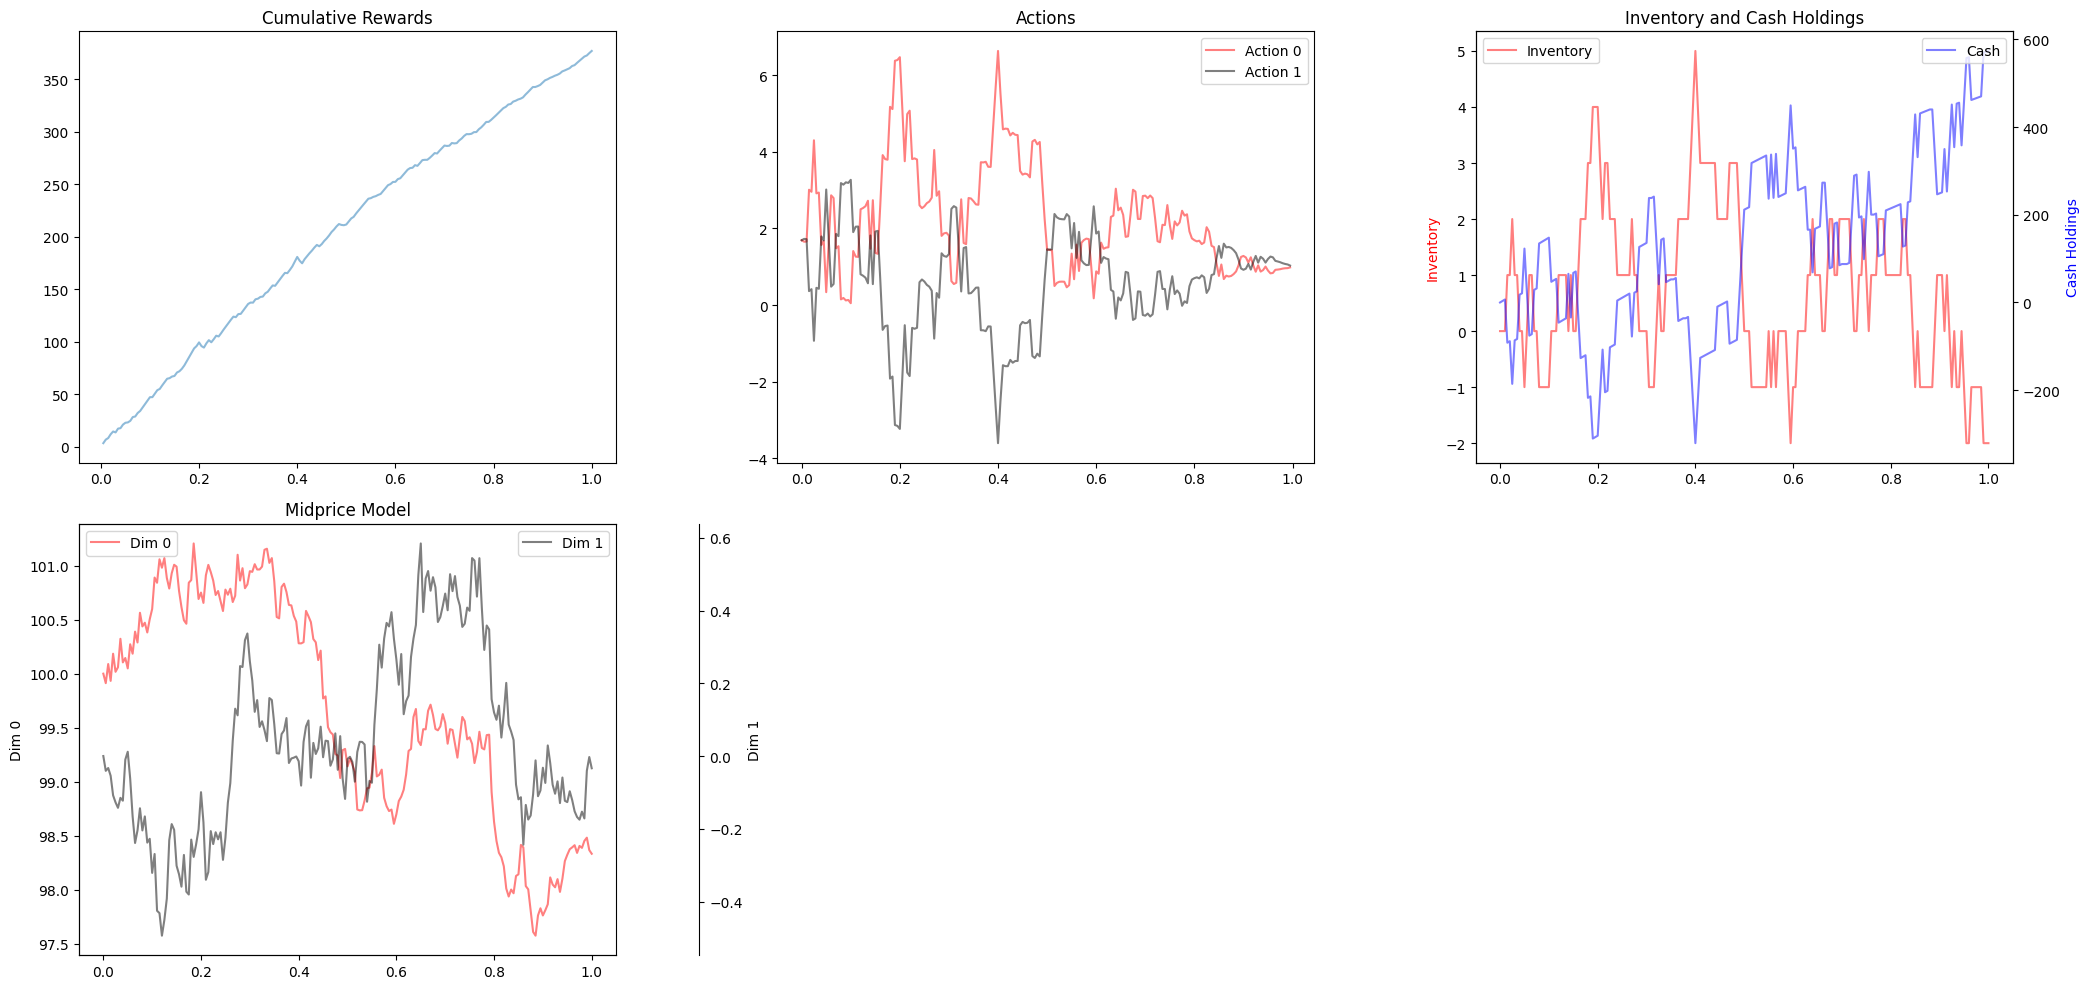

In [20]:
plot_trajectory_extended(as_env, as_agent, seed = 50)

### Comparing the results to the Avellaneda Stoikov paper $\gamma = 0.1$

In [21]:
num_trajectories = 1000
vec_env = get_as_env(num_trajectories)
vec_as = MMwithFadsInformedUniformedTradersAgent(alpha=0.001, mu=0, eta=10, gamma=1, k=1, psi=0, phi=30, fads_proportion=0, sigma=2, risk_aversion=0.1, env=vec_env)


In [22]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

Step [[ 2.30101294e+00  0.00000000e+00  5.00000000e-03  9.99120219e+01
  -4.06664768e-02]
 [ 2.30101294e+00  0.00000000e+00  5.00000000e-03  1.00177126e+02
   5.67487100e-03]
 [-9.88494935e+01  1.00000000e+00  5.00000000e-03  9.98442040e+01
  -2.29029497e-02]
 ...
 [ 2.30101294e+00  0.00000000e+00  5.00000000e-03  9.99421138e+01
  -2.27761171e-02]
 [-9.88494935e+01  1.00000000e+00  5.00000000e-03  1.00091706e+02
  -3.97115666e-02]
 [ 2.30101294e+00  0.00000000e+00  5.00000000e-03  9.98654116e+01
   1.07278402e-02]]
Step [[-9.64605025e+01  1.00000000e+00  1.00000000e-02  9.99150073e+01
  -2.76975135e-02]
 [ 1.03628646e+02 -1.00000000e+00  1.00000000e-02  1.00184342e+02
  -2.76360333e-02]
 [-1.97242178e+02  2.00000000e+00  1.00000000e-02  9.99971923e+01
   4.13742201e-02]
 ...
 [ 1.03393633e+02 -1.00000000e+00  1.00000000e-02  9.98227940e+01
  -4.19797781e-02]
 [-1.97489681e+02  2.00000000e+00  1.00000000e-02  1.00127899e+02
   1.89006007e-02]
 [ 2.30101294e+00  0.00000000e+00  1.0000000

In [23]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

Step [[ 2.30101294e+00  0.00000000e+00  5.00000000e-03  9.99995722e+01
   3.80807163e-02]
 [-9.88494935e+01  1.00000000e+00  5.00000000e-03  9.99935966e+01
   3.92225787e-02]
 [-9.88494935e+01  1.00000000e+00  5.00000000e-03  9.99843914e+01
  -4.26608806e-02]
 ...
 [ 2.30101294e+00  0.00000000e+00  5.00000000e-03  1.00043458e+02
   5.20404089e-02]
 [ 2.30101294e+00  0.00000000e+00  5.00000000e-03  9.99251240e+01
  -7.75554143e-02]
 [ 2.30101294e+00  0.00000000e+00  5.00000000e-03  1.00111787e+02
  -1.04404083e-01]]
Step [[ 1.03451092e+02 -1.00000000e+00  1.00000000e-02  1.00016861e+02
   2.75938605e-02]
 [-9.65484807e+01  1.00000000e+00  1.00000000e-02  9.98735256e+01
   9.10523332e-02]
 [ 1.98439144e+00  0.00000000e+00  1.00000000e-02  9.97597135e+01
   4.15327009e-02]
 ...
 [ 4.60202581e+00  0.00000000e+00  1.00000000e-02  9.99529367e+01
  -3.73200334e-02]
 [-9.64736047e+01  1.00000000e+00  1.00000000e-02  9.99305864e+01
  -9.38325230e-02]
 [ 1.03563306e+02 -1.00000000e+00  1.0000000

In [24]:
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.270655,318.300036,22.129411,-0.017,9.264702
